In [69]:
pip install faker

In [42]:
import random

In [43]:
import pandas as pd

In [44]:
#importar librerias
fake = Faker("es_MX")

In [45]:
datos = []

for i in range(100):
    datos.append({
        "id_usuario": i + 1,
        "nombre": fake.name(),
        "correo": fake.email(),
        "edad": random.randint(18, 65),
        "seguidores": random.randint(100, 50000),
        "plataforma": random.choice(["TikTok", "Instagram", "YouTube"])
    })

In [46]:
df = pd.DataFrame(datos)

In [47]:
df.head()

,id_usuario,nombre,correo,edad,seguidores,plataforma
0,1,René Mateo Aragón,gallardosonia@example.net,26,22635,Instagram
1,2,Israel Vélez,fridaarredondo@example.com,61,20655,YouTube
2,3,Mariano Burgos,estefania76@example.com,31,9964,Instagram
3,4,Maximiliano Laboy,vanesa23@example.com,34,44032,YouTube
4,5,Ramón Montenegro Guerrero,mitzy57@example.net,59,45082,YouTube


In [48]:
#estadistica descriptiva
df.describe(include="all")

,id_usuario,nombre,correo,edad,seguidores,plataforma
count,100.000000,100,100,100.00000,100.00000,100
unique,NaN,100,100,NaN,NaN,3
top,NaN,René Mateo Aragón,gallardosonia@example.net,NaN,NaN,TikTok
freq,NaN,1,1,NaN,NaN,41
mean,50.500000,NaN,NaN,41.51000,23662.15000,NaN
std,29.011492,NaN,NaN,13.84291,14966.30952,NaN
min,1.000000,NaN,NaN,18.00000,480.00000,NaN
25%,25.750000,NaN,NaN,29.75000,11027.75000,NaN
50%,50.500000,NaN,NaN,41.00000,22382.50000,NaN
75%,75.250000,NaN,NaN,54.00000,34806.50000,NaN


In [49]:
#importar librerias para graficar
import seaborn as sns

In [50]:
import matplotlib.pyplot as plt

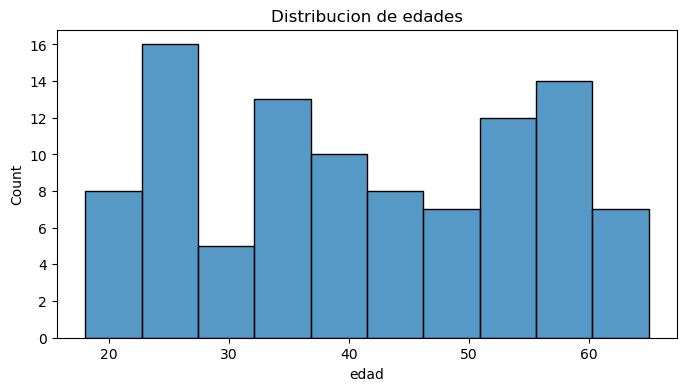

In [53]:
#Distribucion de edades
plt.figure(figsize=(8,4))
sns.histplot(
    df["edad"],
    bins=10
)
plt.title("Distribucion de edades")
plt.show()

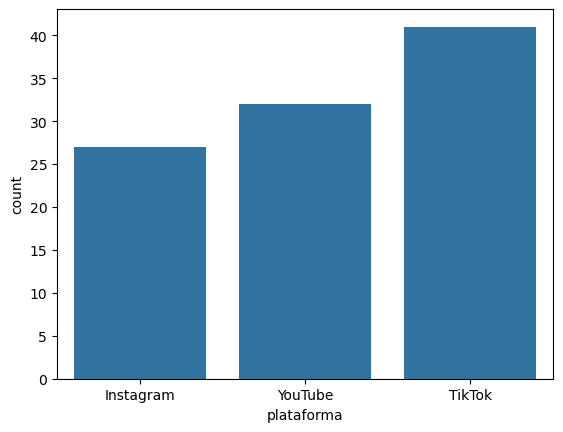

In [54]:
#usuarios por plataforma
sns.countplot(
    x = "plataforma",
    data = df
)
plt.show()

In [55]:
#Generar una copia para contaminarla
df_sucio = df.copy()

In [56]:
#le cololcamos valores nulos
for i in random.sample(range(len(df_sucio)), 5):
    df_sucio.loc[i, "nombre"] = None

In [57]:
df_sucio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id_usuario  100 non-null    int64 
 1   nombre      95 non-null     object
 2   correo      100 non-null    object
 3   edad        100 non-null    int64 
 4   seguidores  100 non-null    int64 
 5   plataforma  100 non-null    object
dtypes: int64(3), object(3)
memory usage: 4.8+ KB


In [58]:
#edades invalidad
for i in random.sample(range(len(df_sucio)), 5):
    df_sucio.loc[i, "edad"] = -10

In [59]:
df_sucio.describe()["edad"]

count    100.00000
mean      38.93000
std       17.61614
min      -10.00000
25%       26.00000
50%       40.50000
75%       54.00000
max       65.00000
Name: edad, dtype: float64

In [60]:
#seguidores imposibles
for i in random.sample(range(len(df_sucio)), 5):
    df_sucio.loc[i, "seguidores"] = 5000000

In [61]:
df_sucio.describe()["seguidores"]

count    1.000000e+02
mean     2.728048e+05
std      1.090051e+06
min      6.280000e+02
25%      1.299450e+04
50%      2.400500e+04
75%      3.812450e+04
max      5.000000e+06
Name: seguidores, dtype: float64

In [64]:
#generar correos invalidos
for i in random.sample(range(len(df_sucio)), 5):
    df_sucio.loc[i, "correo"] = "correo_invalido"

In [67]:
df_sucio.describe(include="object")

,nombre,correo,plataforma
count,95,100,100
unique,95,92,3
top,René Mateo Aragón,correo_invalido,TikTok
freq,1,9,41


In [70]:
df_sucio.isnull().sum()

id_usuario    0
nombre        5
correo        0
edad          0
seguidores    0
plataforma    0
dtype: int64

In [71]:
#estadisticas
df_sucio.describe(include="all")

,id_usuario,nombre,correo,edad,seguidores,plataforma
count,100.000000,95,100,100.00000,1.000000e+02,100
unique,NaN,95,92,NaN,NaN,3
top,NaN,René Mateo Aragón,correo_invalido,NaN,NaN,TikTok
freq,NaN,1,9,NaN,NaN,41
mean,50.500000,NaN,NaN,38.93000,2.728048e+05,NaN
std,29.011492,NaN,NaN,17.61614,1.090051e+06,NaN
min,1.000000,NaN,NaN,-10.00000,6.280000e+02,NaN
25%,25.750000,NaN,NaN,26.00000,1.299450e+04,NaN
50%,50.500000,NaN,NaN,40.50000,2.400500e+04,NaN
75%,75.250000,NaN,NaN,54.00000,3.812450e+04,NaN


In [72]:
pd.set_option('display.float_format',lambda x: '%2.f' % x )

In [73]:
#estadisticas
df_sucio.describe(include="all")

,id_usuario,nombre,correo,edad,seguidores,plataforma
count,100,95,100,100,100,100
unique,NaN,95,92,NaN,NaN,3
top,NaN,René Mateo Aragón,correo_invalido,NaN,NaN,TikTok
freq,NaN,1,9,NaN,NaN,41
mean,50,NaN,NaN,39,272805,NaN
std,29,NaN,NaN,18,1090051,NaN
min,1,NaN,NaN,-10,628,NaN
25%,26,NaN,NaN,26,12994,NaN
50%,50,NaN,NaN,40,24005,NaN
75%,75,NaN,NaN,54,38124,NaN
